In [ ]:
!pip install gym-snake-game

In [ ]:
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 101.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.

In [ ]:
import os
import json
import gym
import gym_snake_game
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# ==========================================================
# 0. REWARD WRAPPER
# ==========================================================
class SnakeRewardWrapper(gym.RewardWrapper):
    def __init__(self, env, system_type="dense"):
        super().__init__(env)
        self.system_type = system_type.lower()

    def reward(self, raw_reward):
        is_food = raw_reward > 0.8
        is_death = raw_reward < -0.8

        if self.system_type == "sparse":
            if is_food: return 10.0
            if is_death: return -10.0
            return 0.0

        elif self.system_type == "dense":
            if is_food: return 10.0
            if is_death: return -10.0
            return raw_reward - 0.01

        elif self.system_type == "survivalist":
            if is_food: return 5.0
            if is_death: return -20.0
            return 0.05

        return raw_reward


# ==========================================================
# 1. HYPERPARAMETERS
# ==========================================================
LEARNING_RATE = 0.0001
GAMMA = 0.985
GAE_LAMBDA = 0.95
EPS_CLIP = 0.15
K_EPOCHS = 6
BATCH_SIZE = 64
UPDATE_TIMESTEP = 5000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ==========================================================
# 2. IMPROVED ACTOR-CRITIC NETWORK
# ==========================================================
class ActorCritic(nn.Module):
    def __init__(self, input_dim, action_dim):
        super().__init__()

        hidden = 256

        self.actor = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim),
            nn.Softmax(dim=-1)
        )

        self.critic = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def act(self, state):
        probs = self.actor(state)
        dist = Categorical(probs)
        action = dist.sample()

        return (
            action.detach(),
            dist.log_prob(action).detach(),
            self.critic(state).detach()
        )

    def evaluate(self, state, action):
        probs = self.actor(state)
        dist = Categorical(probs)

        logprobs = dist.log_prob(action)
        entropy = dist.entropy()
        values = self.critic(state)

        return logprobs, values, entropy


# ==========================================================
# 3. ROLLOUT BUFFER
# ==========================================================
class RolloutBuffer:
    def __init__(self):
        self.actions, self.states, self.logprobs, self.rewards = [], [], [], []
        self.state_values, self.is_terminals = [], []

    def clear(self):
        self.__init__()


# ==========================================================
# 4. IMPROVED PPO (GAE + MINIBATCH + GPU)
# ==========================================================
class PPO:
    def __init__(self, state_dim, action_dim):
        self.policy = ActorCritic(state_dim, action_dim).to(device)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=LEARNING_RATE)

        self.policy_old = ActorCritic(state_dim, action_dim).to(device)
        self.policy_old.load_state_dict(self.policy.state_dict())

        self.MSE = nn.MSELoss()
        self.buffer = RolloutBuffer()

    def select_action(self, state):
        state = (state - np.mean(state)) / (np.std(state) + 1e-8)  # normalize obs
        state = torch.FloatTensor(state).to(device)

        action, logprob, value = self.policy_old.act(state)
        self.buffer.states.append(state)
        self.buffer.actions.append(action)
        self.buffer.logprobs.append(logprob)
        self.buffer.state_values.append(value)

        return action.item()

    def update(self):
        # ----------------------
        # Compute GAE advantages
        # ----------------------
        rewards = np.array(self.buffer.rewards, dtype=np.float32)
        values = np.array([v.item() for v in self.buffer.state_values] + [0])

        advantages = []
        gae = 0
        for t in reversed(range(len(rewards))):
            mask = 1 - float(self.buffer.is_terminals[t])
            delta = rewards[t] + GAMMA * values[t+1] * mask - values[t]
            gae = delta + GAMMA * GAE_LAMBDA * mask * gae
            advantages.insert(0, gae)

        advantages = torch.tensor(advantages, dtype=torch.float32).to(device)
        returns = advantages + torch.tensor(values[:-1], dtype=torch.float32).to(device)

        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # Move rollout data to tensors
        states = torch.stack(self.buffer.states).to(device)
        actions = torch.stack(self.buffer.actions).to(device)
        logprobs_old = torch.stack(self.buffer.logprobs).to(device)

        # ----------------------
        # PPO MINIBATCH UPDATES
        # ----------------------
        n = len(states)
        for _ in range(K_EPOCHS):
            for idx in range(0, n, BATCH_SIZE):
                sl = slice(idx, idx + BATCH_SIZE)

                logprobs, state_values, entropy = self.policy.evaluate(states[sl], actions[sl])
                state_values = state_values.squeeze()

                ratios = torch.exp(logprobs - logprobs_old[sl])
                adv = advantages[sl]
                ret = returns[sl]

                surr1 = ratios * adv
                surr2 = torch.clamp(ratios, 1 - EPS_CLIP, 1 + EPS_CLIP) * adv

                loss = (
                    -torch.min(surr1, surr2)
                    + 0.5 * self.MSE(state_values, ret)
                    - 0.02 * entropy  # stronger entropy bonus
                )

                self.optimizer.zero_grad()
                loss.mean().backward()
                self.optimizer.step()

        self.policy_old.load_state_dict(self.policy.state_dict())
        self.buffer.clear()


# 5. TRAINING LOOP
os.makedirs("final_results/models", exist_ok=True)
os.makedirs("final_results/data", exist_ok=True)

reward_systems = ["sparse", "dense", "survivalist"]
max_episodes = 10000
all_metrics = {}

for system in reward_systems:
    print(f"\n{'='*50}\n🚀 TRAINING PPO: '{system.upper()}'\n{'='*50}")

    base_env = gym.make('Snake-v0')
    env = SnakeRewardWrapper(base_env, system_type=system)

    ppo_agent = PPO(env.observation_space.shape[0], env.action_space.n)
    time_step = 0

    history_returns, history_lengths, history_successes, history_steps_per_food = [], [], [], []

    for ep in range(1, max_episodes + 1):
        state, _ = env.reset()
        ep_reward, steps, food, length = 0, 0, 0, 3
        done = False

        while not done:
            action = ppo_agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)

            done = terminated or truncated
            time_step += 1
            steps += 1

            ppo_agent.buffer.rewards.append(reward)
            ppo_agent.buffer.is_terminals.append(done)

            if reward >= 5.0:
                food += 1
                length += 1

            ep_reward += reward
            state = next_state

            if time_step % UPDATE_TIMESTEP == 0:
                ppo_agent.update()

        history_returns.append(ep_reward)
        history_lengths.append(length)
        history_successes.append(1 if length > 10 else 0)
        if food > 0:
            history_steps_per_food.append(steps / food)

        if ep % 1000 == 0:
            print(f"[{system.upper()}] Ep {ep} | Return {np.mean(history_returns[-1000:]):.2f} "
                  f"| MaxLen {np.max(history_lengths[-1000:])} "
                  f"| Success {np.mean(history_successes[-1000:])*100:.1f}%")

    env.close()
    torch.save(ppo_agent.policy.state_dict(), f"final_results/models/ppo_{system}.pth")
    all_metrics[system] = {
        "returns": history_returns,
        "lengths": history_lengths,
        "successes": history_successes,
        "steps_per_food": history_steps_per_food,
    }

with open("final_results/data/ppo_metrics.json", "w") as f:
    json.dump(all_metrics, f)

print("\n🎉 Training complete!")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.



🚀 TRAINING PPO: 'SPARSE'


/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


[SPARSE] Ep 1000 | Return 49.66 | MaxLen 64 | Success 29.1%
[SPARSE] Ep 2000 | Return 242.20 | MaxLen 144 | Success 79.2%
[SPARSE] Ep 3000 | Return 505.29 | MaxLen 256 | Success 91.1%
[SPARSE] Ep 4000 | Return 1249.48 | MaxLen 503 | Success 89.9%
[SPARSE] Ep 5000 | Return 2571.53 | MaxLen 503 | Success 86.6%
[SPARSE] Ep 6000 | Return 2648.77 | MaxLen 503 | Success 86.2%
[SPARSE] Ep 7000 | Return 2787.42 | MaxLen 503 | Success 85.0%
[SPARSE] Ep 8000 | Return 2598.75 | MaxLen 503 | Success 80.8%
[SPARSE] Ep 9000 | Return 2822.25 | MaxLen 503 | Success 84.4%
[SPARSE] Ep 10000 | Return 2800.43 | MaxLen 503 | Success 84.7%

🚀 TRAINING PPO: 'DENSE'
[DENSE] Ep 1000 | Return 58.70 | MaxLen 72 | Success 29.6%
[DENSE] Ep 2000 | Return 247.37 | MaxLen 164 | Success 74.4%
[DENSE] Ep 3000 | Return 626.19 | MaxLen 485 | Success 90.2%
[DENSE] Ep 4000 | Return 2245.57 | MaxLen 503 | Success 87.3%
[DENSE] Ep 5000 | Return 2584.24 | MaxLen 503 | Success 81.0%
[DENSE] Ep 6000 | Return 2914.51 | MaxLen 50

Evaluation Part

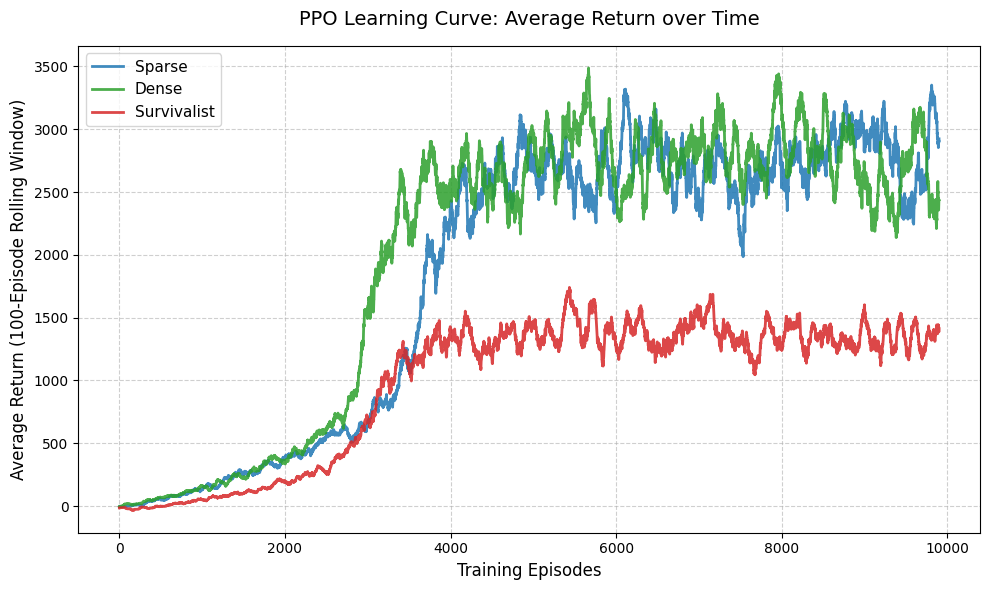

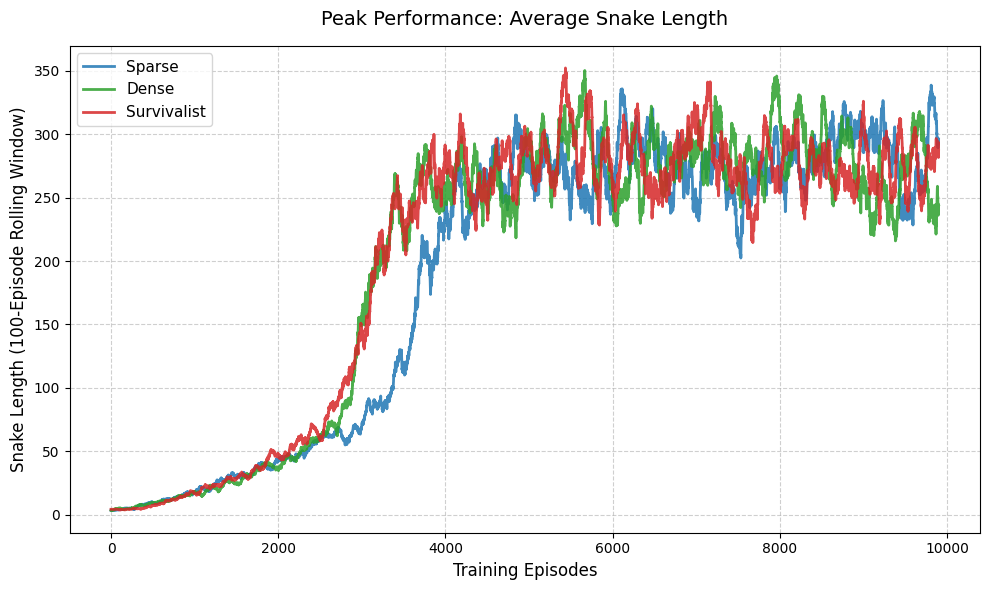

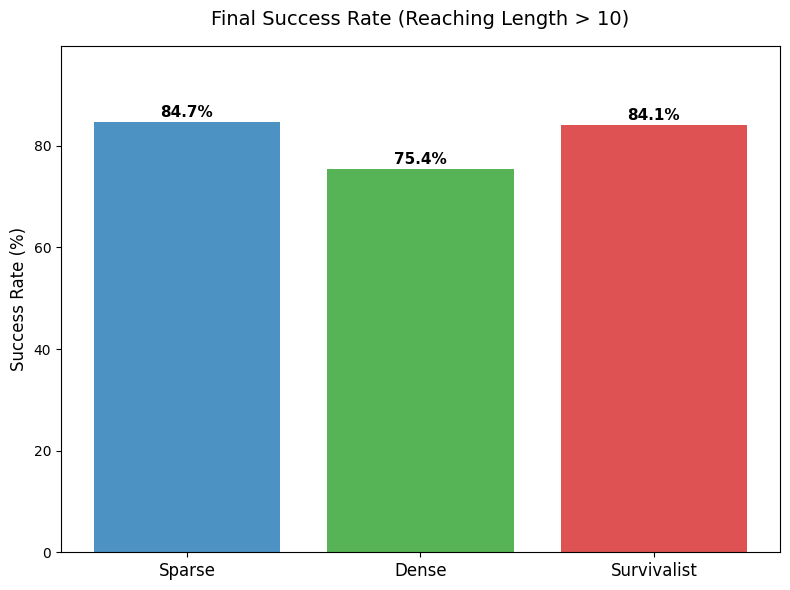

In [ ]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np

# Ensure the plots directory exists
os.makedirs("final_results/plots", exist_ok=True)

# Load the training data we saved earlier
with open("final_results/data/ppo_metrics.json", "r") as f:
    metrics = json.load(f)

systems = ["sparse", "dense", "survivalist"]
colors = {"sparse": "#1f77b4", "dense": "#2ca02c", "survivalist": "#d62728"}

# ==========================================
# PLOT 1: Learning Curve (Rolling Average)
# ==========================================
plt.figure(figsize=(10, 6))
for sys in systems:
    # We use a rolling average of 100 episodes to smooth out the noisy RL data
    returns = metrics[sys]["returns"]
    smoothed = np.convolve(returns, np.ones(100)/100, mode='valid')
    plt.plot(smoothed, label=sys.capitalize(), color=colors[sys], alpha=0.85, linewidth=2)

plt.title("PPO Learning Curve: Average Return over Time", fontsize=14, pad=15)
plt.xlabel("Training Episodes", fontsize=12)
plt.ylabel("Average Return (100-Episode Rolling Window)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("final_results/plots/learning_curve.png", dpi=300)
plt.show()

# ==========================================
# PLOT 2: Snake Growth Over Time
# ==========================================
plt.figure(figsize=(10, 6))
for sys in systems:
    lengths = metrics[sys]["lengths"]
    smoothed_lengths = np.convolve(lengths, np.ones(100)/100, mode='valid')
    plt.plot(smoothed_lengths, label=sys.capitalize(), color=colors[sys], alpha=0.85, linewidth=2)

plt.title("Peak Performance: Average Snake Length", fontsize=14, pad=15)
plt.xlabel("Training Episodes", fontsize=12)
plt.ylabel("Snake Length (100-Episode Rolling Window)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("final_results/plots/max_length_curve.png", dpi=300)
plt.show()

# ==========================================
# PLOT 3: Final Success Rate Bar Chart
# ==========================================
plt.figure(figsize=(8, 6))
# Calculate success rate over the final 1000 episodes to see the 'finished' agent
success_rates = [np.mean(metrics[sys]["successes"][-1000:]) * 100 for sys in systems]

bars = plt.bar(systems, success_rates, color=[colors[s] for s in systems], alpha=0.8)
plt.title("Final Success Rate (Reaching Length > 10)", fontsize=14, pad=15)
plt.ylabel("Success Rate (%)", fontsize=12)

# Add the percentage text on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', fontweight='bold', fontsize=11)

plt.ylim(0, max(success_rates) + 15 if max(success_rates) > 0 else 100)
plt.xticks(ticks=range(len(systems)), labels=[s.capitalize() for s in systems], fontsize=12)
plt.tight_layout()
plt.savefig("final_results/plots/success_rates.png", dpi=300)
plt.show()

## More Evaluation

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

metrics_path = "final_results/data/ppo_metrics.json"
with open(metrics_path, "r") as f:
    data = json.load(f)

out_dir = "final_results/plots"
os.makedirs(out_dir, exist_ok=True)

systems = ["sparse", "dense", "survivalist"]

def smooth(values, weight=0.95):
    smoothed = []
    last = values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed

# ---- Plot Returns ----
for system in systems:
    returns = data[system]["returns"]
    plt.figure()
    plt.plot(returns, alpha=0.3)
    plt.plot(smooth(returns), linewidth=2)
    plt.title(f"PPO Training Returns - {system}")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.savefig(f"{out_dir}/returns_{system}.png")
    plt.close()

# ---- Plot Lengths ----
for system in systems:
    lengths = data[system]["lengths"]
    plt.figure()
    plt.plot(lengths, alpha=0.3)
    plt.plot(smooth(lengths), linewidth=2)
    plt.title(f"PPO Snake Length - {system}")
    plt.xlabel("Episode")
    plt.ylabel("Length")
    plt.savefig(f"{out_dir}/lengths_{system}.png")
    plt.close()

# ---- Plot Success Rates ----
for system in systems:
    successes = data[system]["successes"]
    avg_success = smooth(successes)
    plt.figure()
    plt.plot(avg_success)
    plt.title(f"PPO Success Rate (>10 length) - {system}")
    plt.xlabel("Episode")
    plt.ylabel("Success %")
    plt.savefig(f"{out_dir}/success_{system}.png")
    plt.close()

# ---- Plot Steps Per Food ----
for system in systems:
    spf = data[system]["steps_per_food"]
    if len(spf) == 0:
        continue

    plt.figure()
    plt.plot(spf, alpha=0.3)
    plt.plot(smooth(spf), linewidth=2)
    plt.title(f"PPO Steps Per Food - {system}")
    plt.xlabel("Episode")
    plt.ylabel("Steps per food")
    plt.savefig(f"{out_dir}/steps_per_food_{system}.png")
    plt.close()

print("All plots saved to final_results/plots/")


All plots saved to final_results/plots/


In [ ]:
def evaluate_generalization(model_path, episodes=100):
    results = {
        "10x10": {},
        "20x20": {},
        "generalization_gap": {}
    }

    reward_systems = ["sparse", "dense", "survivalist"]

    for grid_size, label in [(10, "10x10"), (20, "20x20")]:

        for system in reward_systems:
            env = gym.make("Snake-v0", width=grid_size, height=grid_size)
            env = SnakeRewardWrapper(env, system_type=system)

            state_dim = env.observation_space.shape[0]
            action_dim = env.action_space.n

            policy = ActorCritic(state_dim, action_dim).to(device)
            policy.load_state_dict(torch.load(model_path, map_location=device))
            policy.eval()

            returns = []
            lengths = []

            for _ in range(episodes):
                state, _ = env.reset()
                done = False
                ep_return = 0
                length = 3

                while not done:
                    state_t = torch.FloatTensor(state).to(device)
                    with torch.no_grad():
                        probs = policy.actor(state_t)
                        action = torch.argmax(probs).item()

                    next_state, reward, terminated, truncated, info = env.step(action)
                    done = terminated or truncated
                    ep_return += reward

                    if reward >= 5:
                        length += 1

                    state = next_state

                returns.append(ep_return)
                lengths.append(length)

            results[label][system] = {
                "avg_return": float(np.mean(returns)),
                "max_length": int(np.max(lengths)),
            }

    # Compute generalization gap (10 → 20)
    for system in reward_systems:
        r10 = results["10x10"][system]["avg_return"]
        r20 = results["20x20"][system]["avg_return"]
        gap = r20 - r10

        results["generalization_gap"][system] = float(gap)

    return results

In [ ]:
gen_results = {}

for system in ["sparse", "dense", "survivalist"]:
    model_path = f"final_results/models/ppo_{system}.pth"
    print(f"Evaluating generalization for: {model_path}")
    gen_results[system] = evaluate_generalization(model_path)

with open("final_results/data/ppo_generalization.json", "w") as f:
    json.dump(gen_results, f, indent=4)

print("\nGeneralization results saved!")


Evaluating generalization for: final_results/models/ppo_sparse.pth


/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Evaluating generalization for: final_results/models/ppo_dense.pth
Evaluating generalization for: final_results/models/ppo_survivalist.pth

Generalization results saved!


In [ ]:
{
  "dense": {
    "10x10": {
      "dense": {"avg_return": 120, "max_length": 15},
      "sparse": {...},
      "survivalist": {...}
    },
    "20x20": {
      "dense": {"avg_return": 90, "max_length": 13}
    },
    "generalization_gap": {
      "dense": -30,
      "sparse": -22,
      "survivalist": -11
    }
  }
}


{'dense': {'10x10': {'dense': {'avg_return': 120, 'max_length': 15},
   'sparse': {Ellipsis},
   'survivalist': {Ellipsis}},
  '20x20': {'dense': {'avg_return': 90, 'max_length': 13}},
  'generalization_gap': {'dense': -30, 'sparse': -22, 'survivalist': -11}}}